# 申万 vs 中信：行业分类并排对比

本 notebook 将**申万一级**与**中信一级**两套行业分类体系在同一窗口、同一参数下逐段并排回测，用于对比「行业分类换用中信」对 RRG 轮动策略的影响。

**A/B 公平性**：窗口、top_n=6、fees=3e-4、slippage=0、init_cash=1e7、rebalance/on_change、preset、月末采样口径两侧逐项相同；**唯一按体系不同的入参是 `exclude`（剔除集）与行业指数价格表**，其余全部走同一 helper / 同一引擎，保证差异可干净归因。

| 体系 | classification | exclude | 行业指数价格 |
|---|---|---|---|
| SW_申万 | `sw`（31 个一级） | `801230.SI`（综合） | `get_sw_industry_data` |
| ZX_中信 | `zx`（30 个一级） | `CI005029.CI` + `CI005030.CI`（综合 + 综合金融） | `fetch_zx_industry_data` |

覆盖段落：RRG 图 → 单象限 → 组合象限 → 扩散 → 扩散+RRG → 动态 PIT ETF 组合 → 汇总对照表。

> ETF 段只做「动态 PIT 选标的」一条链（生产口径）；原 notebook 的「口径A 关键词 / 口径B reconciled」两臂与「行业树持仓热力图」不复刻——它们依赖 `etf_sw_mapping.csv`（含持仓热力图的 ETF 简称标注，同样依赖该 CSV），非本次对比目标。

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

_project_root = Path().cwd().resolve().parent

sys.path.insert(0, str(_project_root))


import matplotlib.pyplot as plt
import src.plotting as plotting  # noqa: E402
from src.backtest import build_exposure_panel  # noqa: E402
from src.backtest import (build_dynamic_representative_panel, mask_listed,  # noqa: E402
                          portfolio_stats, run_signal_backtest, run_vbt_backtest)
from src.data_provider import (fetch_etf_daily, fetch_etf_meta,  # noqa: E402
                               fetch_zx_industry_data, get_sw_industry_data)
from src.exposure import ETFExposureBuilder  # noqa: E402
from src.generator import RRGSignalGenerator  # noqa: E402
from src.optimizer import batch_optimize  # noqa: E402
from src.store import RRGStore  # noqa: E402
from src.utils import month_end_dates  # noqa: E402

# 压掉 vectorbt 对分组数据不支持部分 subplot 的重复告警（每张组合图刷 2 次）
warnings.filterwarnings("ignore", message="Subplot .* does not support grouped data")

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]

# 全 notebook 共用单一 DuckDB 缓存连接，显式锚定根库 data/etf_rrg.duckdb。
# 不传 store 则各 ETFExposureBuilder 走默认相对路径 data/etf_rrg.duckdb，
# cwd=example/ 时会在 example/data 下另起独立缓存库 → 与根库分裂、增量缓存互不复用。
store = RRGStore(_project_root / "data" / "etf_rrg.duckdb")

In [2]:
start_date = "2021-01-01"   # 信号窗口起点（含 RRG warm-up ~318 日）
end_date = "2026-08-31"
backtest_start = "2022-09-01"   # 实际回测起点（warm-up 之后）

# ⚠️ 中信成分源自 PG zx_index_member；2015-06-30 覆盖约 64%，
# 早于 2019-12-02 默认 fail-loud（直接取数时确知后果可显式放行）。
# start_date 会再前移 240 个交易日，前移后须仍在成分可用窗口内；
# 且 2014–2015 只有 29 个一级行业，少 1 个。

# 两套体系的唯一差异 = 行业分类与剔除集；其余参数逐项相同，保证差异可干净归因
SCHEMES = {
    "SW_申万": {"classification": "sw", "exclude": ["801230.SI"]},
    "ZX_中信": {"classification": "zx", "exclude": ["CI005029.CI", "CI005030.CI"]},
}
gens = {
    k: RRGSignalGenerator(start_date=start_date, end_date=end_date,
                          classification=v["classification"])
    for k, v in SCHEMES.items()
}

# 相对旋转图 (RRG)
相对旋转图 (Relative Rotation Graphs, RRG) 由 Julius de Kempenaer 于 2004-2005 年开发, 用于直观表示证券的相对表现。RRG 的横轴和纵轴分别为 RS-Ratio 和 RS-Momentum，均依赖于相对强度(RS)计算。

## 相对强度 RS

相对强度也称相对价格、相对强弱, 通过对比两种证券的价格, 衡量证券走势的强弱。

$$
\text{ 相对强度 }\mathrm{{RS}} = \frac{\text{ 证券价格 }}{\text{ 基准价格 }} * {100}
$$

## RS-Ratio

RS-Ratio 是 RS 的变化率，衡量 RS 的趋势强度。

$$
{RSrati}{o}_{\text{ ori }} = {100} * \frac{R{S}_{t}}{R{S}_{t - T}}
$$

$$
\text{ RSratio } = {MA}\left( {{\text{ RSratio }}_{\text{ ori }}, T}\right)
$$

经标准化后, RS-Ratio 数值在 100 以上时, 表示相对强度处于上升趋势 (证券相对基准越来越强); 在 100 以下时, 表示相对强度处于下降趋势 (证券相对基准越来越弱)。

## RS-Momentum

RS-Momentum 是衡量 RS-Ratio 变化率的指标。

$$
{\text{ RSmon }}_{\text{ ori }} = {100} * \frac{{RSratio}_{t}}{{RSratio}_{t - T}}
$$

$$
{RSmom} = {MA}\left( {{RSmo}{n}_{ori}, T}\right)
$$

RS-Momentum 作为 RS-Ratio 的动量, 引导着 RS-Ratio 的变化, 可以用来预测 RS-Ratio 的转向。通常, 当 RS-Ratio 形成低谷并开始上升时, RS-Momentum 超过 100。 相反, 当 RS-Ratio 形成峰值并开始下降时, RS-Momentum 跌破 100 。理想情况下, RRG 图呈现顺时针旋转 (图 1)。

### RRG 图 · SW_申万 ###


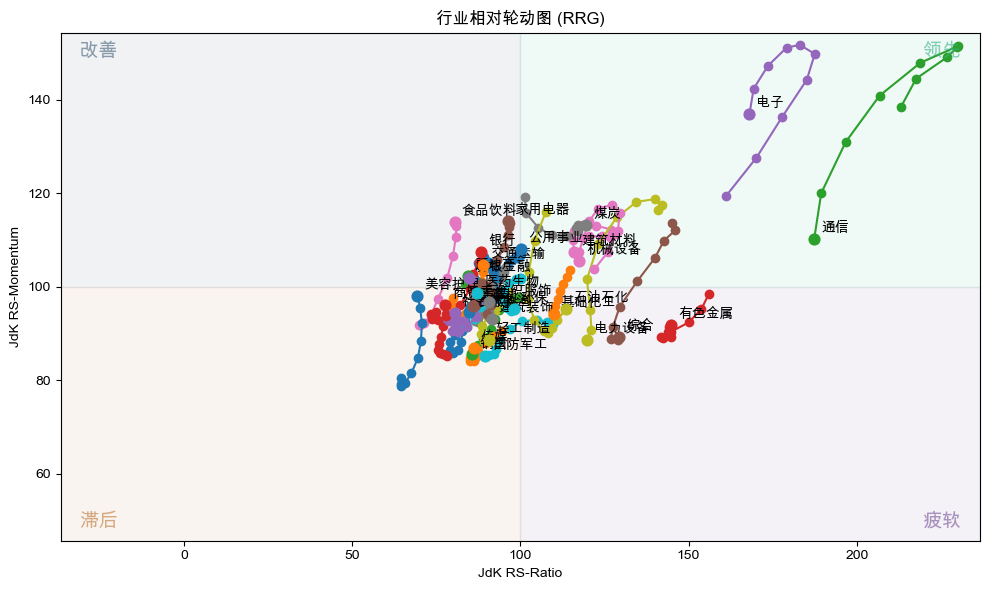

### RRG 图 · ZX_中信 ###


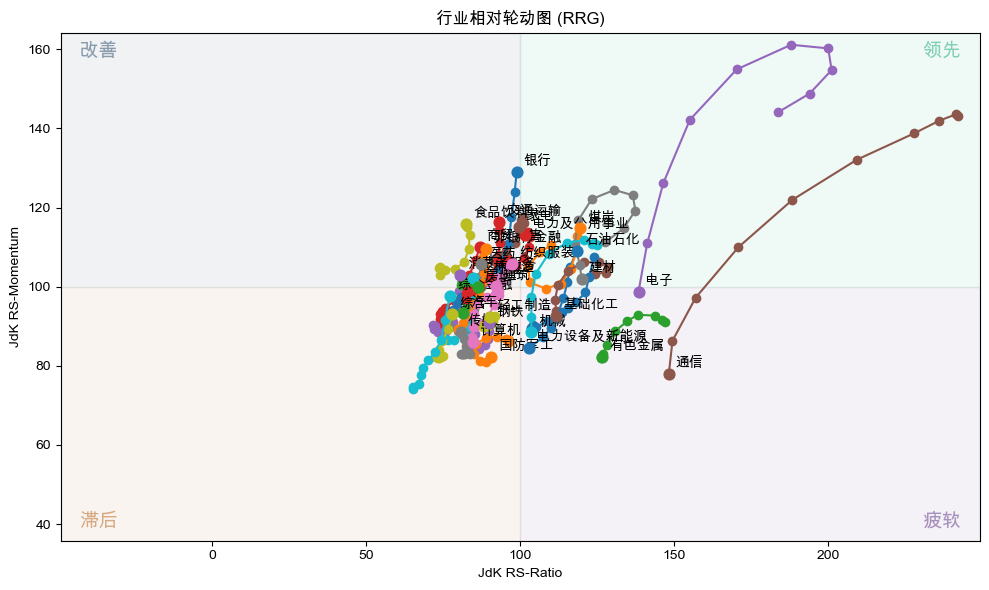

In [3]:
# 基准 = 各自体系的行业等权组合净值（研报 §2.1 口径），benchmark_exclude 走
# 生成器默认 "auto"：sw → 剔「综合」；zx → 剔「综合 + 综合金融」（研报原文口径）。
# 两张图各画各的：行业代码 / 名称 / 等权篮子均随 classification 切换。
for name, gen in gens.items():
    rs_ratio, rs_mom = gen.get_rrg(True)
    print(f"### RRG 图 · {name} ###")
    plotting.plot_rrg_chart(rs_ratio, rs_mom)
    plt.show()

# 行业指数价格

行业指数价格**按体系分别取**：申万走 `get_sw_industry_data`，中信走 `fetch_zx_industry_data`（drop-in 同构长表 `trade_date / code / industry_name / close / open`），回测引擎对两侧完全同构。

In [4]:
# 获取行业指数价格数据（回测区间，含 open 供开盘成交）
prices = {
    "SW_申万": get_sw_industry_data(start_dt=backtest_start, end_dt=end_date,
                                    fields=["close", "open"]),
    "ZX_中信": fetch_zx_industry_data(backtest_start, end_date, fields=("close", "open")),
}
for arm, df in prices.items():
    print(arm, df.shape, df["code"].nunique(), "个行业")

SW_申万 (28830, 5) 31 个行业
ZX_中信 (29010, 5) 30 个行业


In [5]:
def run_arm(scheme: str, signal_kind: str, **kw):
    """跑一个 (体系 × 信号) 组合，返回 (日频 pf, 月末 pf)。

    唯一按体系变化的入参是 exclude 与行业价格表；引擎/费率/on_change 全同。
    """
    sig = gens[scheme].generate(signal_kind, exclude=SCHEMES[scheme]["exclude"], **kw)
    sig_bt = sig.loc[pd.to_datetime(backtest_start):]
    pf_daily = run_signal_backtest(sig_bt, prices[scheme])
    sig_me = sig.loc[month_end_dates(sig.index)]
    pf_me = run_signal_backtest(sig_me.loc[pd.to_datetime(backtest_start):], prices[scheme])
    return pf_daily, pf_me


def compare(pfs: dict) -> pd.DataFrame:
    """单信号两体系 × 日频/月末 绩效对照表。"""
    return pd.concat(
        {arm: pd.concat({"日频": portfolio_stats(pf_d), "月末": portfolio_stats(pf_m)}, axis=1)
         for arm, (pf_d, pf_m) in pfs.items()},
        axis=1,
    )


results: dict[str, dict] = {}   # 信号名 → {体系: (日频 pf, 月末 pf)}，末尾汇总用
print("helper 就绪")

helper 就绪


# RRG 单象限行业轮动

四个单象限信号（欧氏距离 top_n=6），两套体系各跑一遍：日频净值并排出图，日频/月末采样统计并排成表。

In [6]:
QUADRANTS = {"象限1": (1,), "象限2": (2,), "象限3": (3,), "象限4": (4,)}
for name, quads in QUADRANTS.items():
    pfs = {arm: run_arm(arm, "quadrant", quadrants=quads, top_n=6) for arm in SCHEMES}
    results[name] = pfs
    # 日频净值并排（月末版仅入统计表，控制篇幅）
    for arm, (pf_d, _) in pfs.items():
        print(f"### {name} · {arm} · 日频")
        pf_d.plot().show()
    display(compare(pfs))

### 象限1 · SW_申万 · 日频


### 象限1 · ZX_中信 · 日频


SW_申万                   ZX_中信            
                   日频          月末          日频          月末
累计收益率        0.078452    0.229626    0.264908    0.333725
年化收益率        0.020676    0.057610    0.063155    0.077934
最大回撤        -0.314194   -0.262077   -0.280089   -0.241892
年化波动率        0.220860    0.211281    0.215586    0.211860
夏普比率         0.203987    0.371848    0.392209    0.460402
Calmar 比率    0.065807    0.219821    0.225481    0.322186
总成交笔数      835.000000  293.000000  904.000000  306.000000

### 象限2 · SW_申万 · 日频


### 象限2 · ZX_中信 · 日频


...

### 象限3 · ZX_中信 · 日频


SW_申万                   ZX_中信            
                   日频          月末          日频          月末
累计收益率       -0.075224   -0.095584    0.100386    0.051842
年化收益率       -0.020968   -0.026856    0.025243    0.013259
最大回撤        -0.373104   -0.345329   -0.296384   -0.312444
年化波动率        0.192811    0.177788    0.194395    0.168680
夏普比率        -0.013693   -0.063967    0.225356    0.162414
Calmar 比率   -0.056198   -0.077769    0.085168    0.042435
总成交笔数      895.000000  315.000000  997.000000  333.000000

### 象限4 · SW_申万 · 日频


### 象限4 · ZX_中信 · 日频


SW_申万                   ZX_中信            
                   日频          月末          日频          月末
累计收益率        0.042173    0.295418   -0.035120    0.044099
年化收益率        0.011256    0.072654   -0.009274    0.011310
最大回撤        -0.259813   -0.272370   -0.338772   -0.316655
年化波动率        0.193450    0.185642    0.190174    0.170228
夏普比率         0.155169    0.470671    0.046466    0.151303
Calmar 比率    0.043323    0.266745   -0.027374    0.035716
总成交笔数      681.000000  221.000000  675.000000  204.000000

# RRG 组合象限行业轮动

两象限组合信号（1+2 / 1+4 / 3+4 / 2+3），同样两体系并排。

In [7]:
COMBOS = {"象限1+2": (1, 2), "象限1+4": (1, 4), "象限3+4": (3, 4), "象限2+3": (2, 3)}
for name, quads in COMBOS.items():
    pfs = {arm: run_arm(arm, "quadrant", quadrants=quads, top_n=6) for arm in SCHEMES}
    results[name] = pfs
    for arm, (pf_d, _) in pfs.items():
        print(f"### {name} · {arm} · 日频")
        pf_d.plot().show()
    display(compare(pfs))

### 象限1+2 · SW_申万 · 日频


### 象限1+2 · ZX_中信 · 日频


SW_申万                    ZX_中信            
                    日频          月末           日频          月末
累计收益率         0.241805    0.092888     0.362515    0.468597
年化收益率         0.060438    0.024360     0.083950    0.105337
最大回撤         -0.299697   -0.307206    -0.304392   -0.307341
年化波动率         0.214315    0.199431     0.208756    0.207804
夏普比率          0.381514    0.221202     0.490599    0.585827
Calmar 比率     0.201665    0.079296     0.275796    0.342737
总成交笔数      1123.000000  334.000000  1208.000000  322.000000

### 象限1+4 · SW_申万 · 日频


### 象限1+4 · ZX_中信 · 日频


...

### 象限3+4 · ZX_中信 · 日频


SW_申万                    ZX_中信            
                   日频          月末           日频          月末
累计收益率       -0.017473    0.029835     0.124860   -0.075948
年化收益率       -0.004765    0.007998     0.031137   -0.020374
最大回撤        -0.287129   -0.332782    -0.245833   -0.322432
年化波动率        0.187630    0.177882     0.187987    0.164868
夏普比率         0.068597    0.133778     0.257094   -0.042170
Calmar 比率   -0.016596    0.024033     0.126658   -0.063188
总成交笔数      979.000000  342.000000  1126.000000  330.000000

### 象限2+3 · SW_申万 · 日频


### 象限2+3 · ZX_中信 · 日频


SW_申万                   ZX_中信            
                   日频          月末          日频          月末
累计收益率        0.032848   -0.072698    0.105676    0.048428
年化收益率        0.008796   -0.020244    0.026525    0.012400
最大回撤        -0.342453   -0.393288   -0.324099   -0.361767
年化波动率        0.198942    0.188401    0.197987    0.183958
夏普比率         0.142984   -0.014559    0.230823    0.158777
Calmar 比率    0.025686   -0.051473    0.081842    0.034278
总成交笔数      918.000000  289.000000  851.000000  315.000000

# 扩散指标行业轮动

扩散信号（`diffusion`，top_n=6），两体系并排。

> 注：两体系的成分池规模不同（中信约 5,385 只 vs 申万约 5,145 只，2025-06 实测），扩散指标分母属分类体系固有差异，非实现偏差。

In [8]:
name = "扩散"
pfs = {arm: run_arm(arm, "diffusion", top_n=6) for arm in SCHEMES}
results[name] = pfs
for arm, (pf_d, _) in pfs.items():
    print(f"### {name} · {arm} · 日频")
    pf_d.plot().show()
display(compare(pfs))

### 扩散 · SW_申万 · 日频


### 扩散 · ZX_中信 · 日频


SW_申万                   ZX_中信            
                   日频          月末          日频          月末
累计收益率        0.206062    0.359552    0.314763    0.351341
年化收益率        0.052080    0.086791    0.073919    0.081627
最大回撤        -0.217721   -0.197149   -0.196832   -0.194341
年化波动率        0.189607    0.182713    0.190817    0.184970
夏普比率         0.363617    0.547870    0.469686    0.516994
Calmar 比率    0.239203    0.440230    0.375545    0.420017
总成交笔数      569.000000  228.000000  594.000000  264.000000

# 扩散指标+RRG 行业轮动

扩散 + RRG 复合信号（`diffusion_rrg`，top_n=6），两体系并排。

In [9]:
name = "扩散+RRG"
pfs = {arm: run_arm(arm, "diffusion_rrg", top_n=6) for arm in SCHEMES}
results[name] = pfs
for arm, (pf_d, _) in pfs.items():
    print(f"### {name} · {arm} · 日频")
    pf_d.plot().show()
display(compare(pfs))

### 扩散+RRG · SW_申万 · 日频


### 扩散+RRG · ZX_中信 · 日频


SW_申万                   ZX_中信            
                   日频          月末          日频          月末
累计收益率        0.040773    0.096319    0.242967    0.341407
年化收益率        0.010888    0.025231    0.058318    0.079549
最大回撤        -0.345624   -0.299722   -0.288531   -0.225025
年化波动率        0.212249    0.203589    0.223406    0.205912
夏普比率         0.158213    0.225430    0.366231    0.475332
Calmar 比率    0.031502    0.084181    0.202120    0.353511
总成交笔数      572.000000  217.000000  558.000000  216.000000

# 扩散指标+RRG ETF 轮动 · 动态 PIT 选标的（生产口径 · 全市场）

七段链：候选池+行情 → RRG 信号（行业层）+月末采样 → 真实持仓行业权重+动态选代表 → 暴露矩阵 `E_t` → 优化 → 上市防呆 → vbt 回测。

- ETF 候选池与行情（`meta` / `adjclose` / `adjopen` / `amount`）**与行业分类无关，两臂共用一次抓取**；
- 按体系变化的只有两处：信号 `exclude`、`ETFExposureBuilder(classification=...)`（个股行业归类的分类体系，决定行业权重与主导行业选代表）；
- `fees=3e-4, slippage=0.0, init_cash=1e7` 两侧不变。

> **口径说明（2026-08-31 重跑）**：本段数字基于修正后的暴露矩阵分母（`aggregate_industry_weights` 用基金净值 `stk_mkv_ratio`，非「已披露持仓 mkv 之和」）与 LP 残渣截断。**此前版本的中信 63.5% / 申万 17.7% 已作废**——那组数字来自缺陷口径，浅披露 ETF 的行业权重被虚高到 1.0，且数值残渣被撮合成真实交易多计了手续费。
>
> 另注：本段用的是**代表池**（每行业 ADV top1，约 30 只）+ `etf_capped`。`docs/RRG复现偏离分析_20260618.md` §3.7 已判定**研报口径的全池**才是主因所在，故本段并非与研报可比的口径。


In [10]:
# 候选 ETF 池 + 共享行情（剔未上市 / QDII）——与行业分类无关，两臂共用
meta = fetch_etf_meta(only_listed=True, drop_qdii=True)
codes = sorted(meta.index)                       # 或你自己的 universe
adjclose, adjopen, amount = fetch_etf_daily(codes=codes, start_date=start_date,
                                            end_date=end_date, lookback=25)
print("ETF 池:", len(codes), "只")

ETF 池: 1571 只


In [11]:
# ① RRG 信号（行业层日频，按体系 exclude）→ ② 月末采样
# ③ 真实持仓行业权重（DuckDB 增量缓存 + PIT，classification 按体系切换）
#    + 当期主导行业动态选代表 ETF（无前视）
# ④ 暴露矩阵 → ⑤ 优化 → ⑥ 防呆 → ⑦ 回测
etf_industry_weights: dict[str, pd.DataFrame] = {}
pf_etf: dict = {}
score_panels, reps_panels, weight_panels = {}, {}, {}   # 供下方「行业→ETF 持仓面板」复用
for arm in SCHEMES:
    print(f"### 动态 PIT · {arm}")
    mask = gens[arm].generate("diffusion_rrg", top_n=6, keep_quadrants=(1, 2),
                              exclude=SCHEMES[arm]["exclude"])
    me = month_end_dates(mask.index)
    score_panel = mask.loc[me].astype(float)

    with ETFExposureBuilder(codes=codes, start_date=start_date, end_date=end_date,
                            store=store,
                            classification=SCHEMES[arm]["classification"]) as builder:
        industry_weights = builder.build_industry_weights()
    etf_industry_weights[arm] = industry_weights

    reps = build_dynamic_representative_panel(
        industry_weights, amount, me,
        lookback=20, min_dominant_weight=0.5, top_n=1,
    )
    exposures = build_exposure_panel(reps, industry_weights)
    vdates = [d for d in me if d in exposures]
    w = batch_optimize(score_panel.loc[vdates], exposures=exposures, dates=vdates,
                       preset="etf_capped", strict=False)
    w = mask_listed(w, meta)
    score_panels[arm], reps_panels[arm], weight_panels[arm] = score_panel, reps, w
    common = w.columns.intersection(adjclose.columns)

    ww = w[common].loc[backtest_start:]
    c = adjclose[common].loc[backtest_start:]
    o = adjopen[common].loc[backtest_start:]
    pf_etf[arm] = run_vbt_backtest(ww, c, o, fees=3e-4, slippage=0.0, init_cash=1e7)

### 动态 PIT · SW_申万


src/optimizer.py:169: UserWarning: 可投 ETF 仅 3 只（单只上限 0.2），仓位由 0.800 降为 0.600——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 4 只（单只上限 0.2），仓位由 1.000 降为 0.800——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 3 只（单只上限 0.2），仓位由 1.000 降为 0.600——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 1 只（单只上限 0.2），仓位由 0.400 降为 0.200——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(


### 动态 PIT · ZX_中信


src/optimizer.py:169: UserWarning: 可投 ETF 仅 3 只（单只上限 0.2），仓位由 0.800 降为 0.600——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 2 只（单只上限 0.2），仓位由 0.800 降为 0.400——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 3 只（单只上限 0.2），仓位由 1.000 降为 0.600——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 1 只（单只上限 0.2），仓位由 0.600 降为 0.200——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 3 只（单只上限 0.2），仓位由 0.800 降为 0.600——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 4 只（单只上限 0.2），仓位由 1.000 降为 0.800——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 4 只（单只上限 0.2），仓位由 1.000 降为 0.800——多出的仓位不会撒到零目标 ETF 上
  return optimize_etf_weights(
src/optimizer.py:169: UserWarning: 可投 ETF 仅 4 只（单只上限 0.2），仓位由 1.000 降为 0.800——多出的仓位不会撒到零目标 ETF 上
  retur

In [12]:
# 行业权重表末几行（两体系行业集合不同：SW 31 个 / ZX 30 个）
for arm, iw in etf_industry_weights.items():
    print(f"### 行业权重 · {arm}")
    display(iw.tail())

### 行业权重 · SW_申万


,code,end_date,ann_date,sw_code,weight
170492,589990.SH,2026-03-31,2026-04-22,801150.SI,0.0119
170493,589990.SH,2026-03-31,2026-04-22,801750.SI,0.0094
170494,589990.SH,2026-06-30,2026-07-21,801080.SI,0.2954
170495,589990.SH,2026-06-30,2026-07-21,801740.SI,0.0002
170496,589990.SH,2026-06-30,2026-07-21,801890.SI,0.0004


### 行业权重 · ZX_中信


,code,end_date,ann_date,sw_code,weight
146505,589990.SH,2026-03-31,2026-04-22,CI005025.CI,0.1910
146506,589990.SH,2026-03-31,2026-04-22,CI005027.CI,0.0094
146507,589990.SH,2026-06-30,2026-07-21,CI005010.CI,0.0004
146508,589990.SH,2026-06-30,2026-07-21,CI005012.CI,0.0002
146509,589990.SH,2026-06-30,2026-07-21,CI005025.CI,0.2950


In [13]:
for arm, pf in pf_etf.items():
    print(f"### 动态 PIT ETF 组合 · {arm}")
    pf.plot().show()

# 两体系 ETF 段绩效对照
display(pd.concat({arm: portfolio_stats(pf) for arm, pf in pf_etf.items()}, axis=1))

### 动态 PIT ETF 组合 · SW_申万


### 动态 PIT ETF 组合 · ZX_中信


,SW_申万,ZX_中信
累计收益率,0.732316,0.510729
年化收益率,0.153777,0.113391
最大回撤,-0.229932,-0.215578
年化波动率,0.225251,0.204130
夏普比率,0.748174,0.628554
Calmar 比率,0.668795,0.525985
总成交笔数,172.000000,163.000000


### 行业信号 → 代表 ETF 持仓面板

`plot_industry_holding_panel`：行 = 窗口内至少被选中过一次的行业，列 = 换仓日，
**实心格** = 该期该行业代表 ETF 拿到的 LP 权重（深 = 大，格内 = 简称 + 权重），
**空心框** = 信号选中但没拿到权重（无合格代表 ETF / LP 未分配），灰 = 未选中。
沿一列往下读就是「这期选了哪些行业 → 各自落地成了哪只 ETF、多少仓」。
行数只随行业走，不随 ETF 数膨胀；默认看最近 24 期，全窗口把 `dates=` 去掉即可。


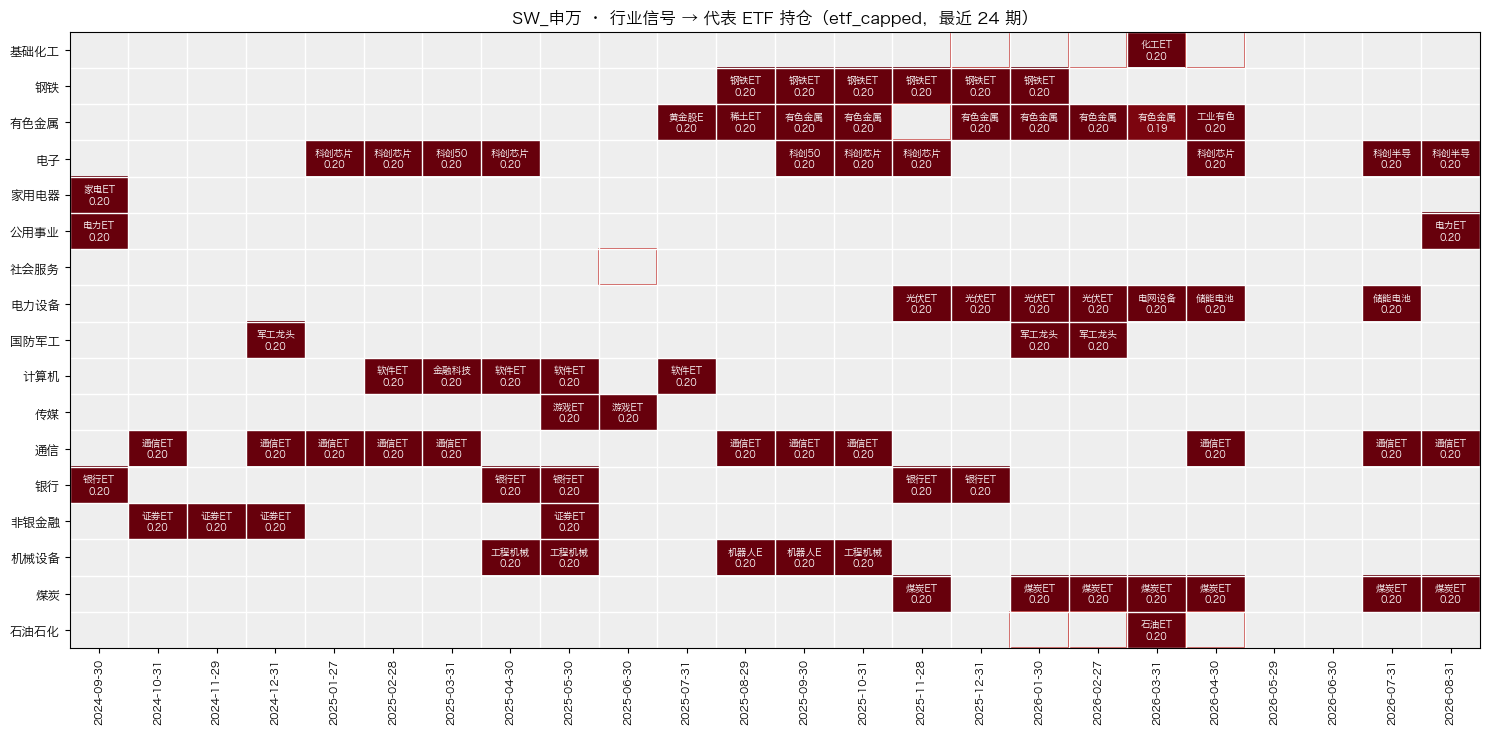

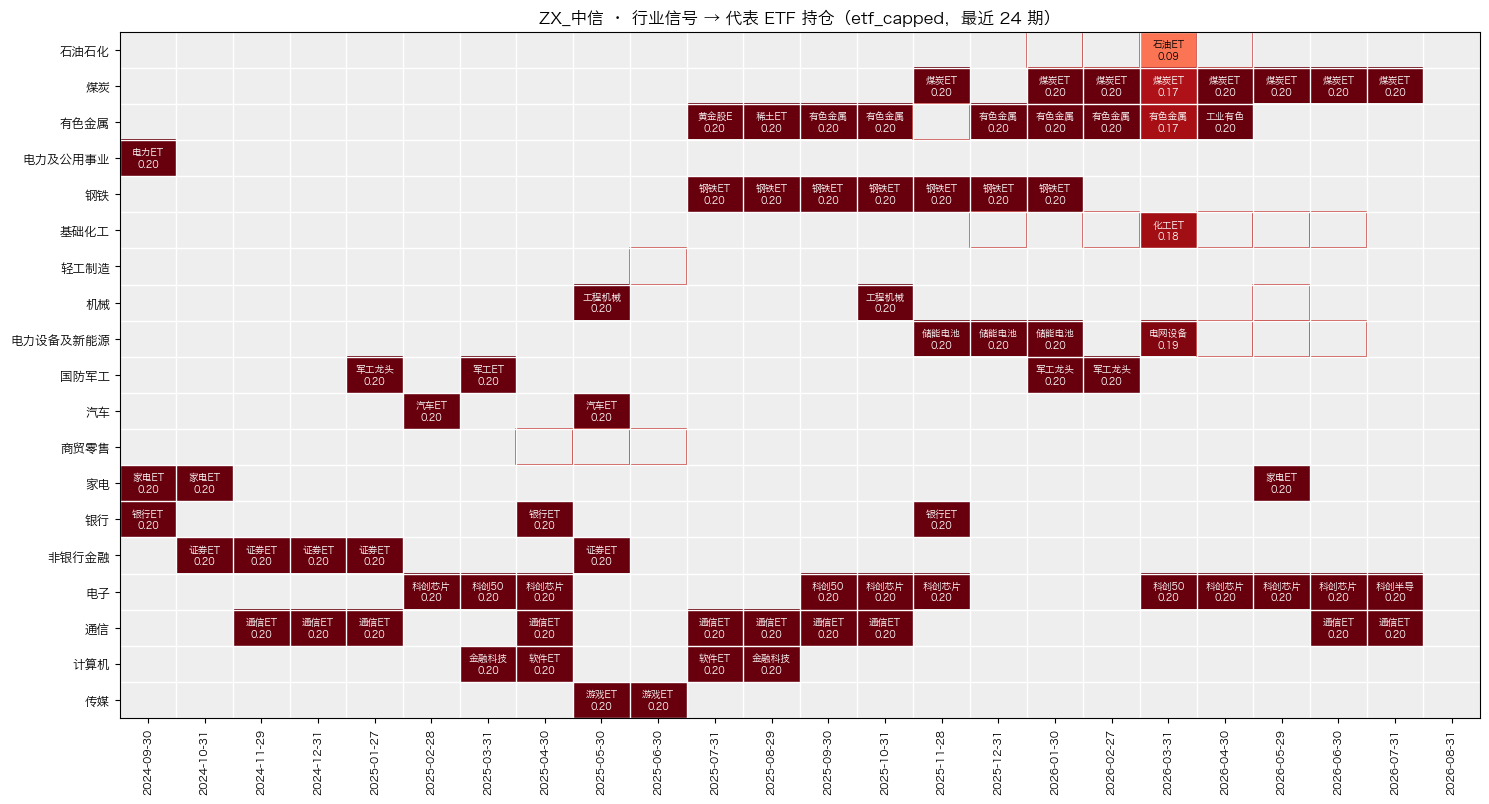

In [14]:
from src.plotting import plot_industry_holding_panel

# ETF 简称：映射表的 etf_name，缺的回退跟踪指数名
_m = pd.read_csv("../data/etf_sw_mapping.csv")
etf2name = {**meta["index_name"].dropna().to_dict(), **_m.set_index("etf_code")["etf_name"].to_dict()}

for arm in SCHEMES:
    _dates = weight_panels[arm].index[-24:]          # 最近 24 期；全窗口：dates=None
    fig = plot_industry_holding_panel(
        score_panels[arm], reps_panels[arm], weight_panels[arm],
        industry_name=gens[arm].code2name, etf_name=etf2name, dates=_dates,
        title=f"{arm} · 行业信号 → 代表 ETF 持仓（etf_capped，最近 24 期）",
    )
    plt.show()


# 研报口径候选池下的 SW/ZX 对照

上一段用的是**代表池**（每个行业只留 ADV top1，约 30 只）。而 `docs/RRG复现偏离分析_20260618.md` §3.7 已判定：**候选池才是复现差距的主因**——研报 §3.1 原文是「已上市的所有行业和主题 ETF，同一指数只保留过去 20 日日均成交额最高的那只，全池整体交给 LP」，约 436 只（已剔除持仓 >50% 为港股的 ETF）。

本段用**研报口径全池**重做 SW/ZX 对照，这才是与研报可比、也最贴近「换用中信是否有提高」这一问题的口径。跑两个研报变体：

- `base`（研报 §3.1）：满仓 Σw=1，每行业暴露 ≤1/k
- `unconstrained`（研报 §3.3）：无行业上限、单 ETF ≤1、Σw≤1 —— 研报明述该变体「多数时期仅持有 1 到 2 只 ETF」，是高弹性高波变体

> 信号、窗口、费率、调仓频率与上一段完全相同；**唯一变量是候选池与优化变体**。

In [15]:
# 研报 §3.1 口径候选池（全池 + 同指数 ADV top1 + 剔境外）下的 SW/ZX 对照
from src.backtest import build_overseas_share, build_report_universe_panel

# 境外占比按真实持仓穿透判定（PIT）——港股 ETF 在 A 股行业表里查不到标的、
# 拿不到任何行业暴露，留在池中只会虚占指数槽位
with ETFExposureBuilder(codes=codes, start_date=start_date, end_date=end_date,
                        store=store, classification="zx") as _b:
    _ovs = build_overseas_share(_b.load_portfolio())

pf_report: dict = {}
for arm in SCHEMES:
    mask_r = gens[arm].generate("diffusion_rrg", top_n=6, keep_quadrants=(1, 2),
                                exclude=SCHEMES[arm]["exclude"])
    me_r = month_end_dates(mask_r.index)
    score_r = mask_r.loc[me_r].astype(float)
    iw_r = etf_industry_weights[arm]              # 复用上一段已算好的行业权重
    panel_r = build_report_universe_panel(meta, amount, me_r, lookback=20,
                                          overseas_share=_ovs, overseas_threshold=0.5)
    expo_r = build_exposure_panel(panel_r, iw_r)
    vd_r = [d for d in me_r if d in expo_r]
    for preset in ("base", "unconstrained"):
        w_r = mask_listed(batch_optimize(score_r.loc[vd_r], exposures=expo_r,
                                         dates=vd_r, preset=preset, strict=False), meta)
        cm_r = w_r.columns.intersection(adjclose.columns)
        pf_report[f"{arm}·{preset}"] = run_vbt_backtest(
            w_r[cm_r].loc[backtest_start:], adjclose[cm_r].loc[backtest_start:],
            adjopen[cm_r].loc[backtest_start:],
            fees=3e-4, slippage=0.0, init_cash=1e7)
    print(f"{arm}: 池子 {panel_r.shape[1]} 列｜有暴露的换仓日 {len(vd_r)}")

display(pd.concat({k: portfolio_stats(v) for k, v in pf_report.items()}, axis=1))

SW_申万: 池子 443 列｜有暴露的换仓日 68


ZX_中信: 池子 443 列｜有暴露的换仓日 68


,SW_申万·base,SW_申万·unconstrained,ZX_中信·base,ZX_中信·unconstrained
累计收益率,0.380294,1.007882,0.576655,1.142711
年化收益率,0.087524,0.198980,0.125841,0.219439
最大回撤,-0.187420,-0.219837,-0.177532,-0.349423
年化波动率,0.192837,0.280515,0.210568,0.322036
夏普比率,0.531609,0.786647,0.668052,0.776778
Calmar 比率,0.466996,0.905125,0.708833,0.628002
总成交笔数,216.000000,61.000000,214.000000,65.000000


**净值曲线（四臂并排）**：实线 = 申万，虚线 = 中信；蓝 = `base`，橙 = `unconstrained`。
竖线 2025-07-01 是下方分段归因用的边界——两个 `unconstrained` 臂的收益几乎全部堆在竖线右侧，
与 §3.7「优势高度集中在最后 12 个月」的判定一致。用 matplotlib 而非 `pf.plot()`（plotly 会把 `metadata.widgets` 撑到 100 MB+）。


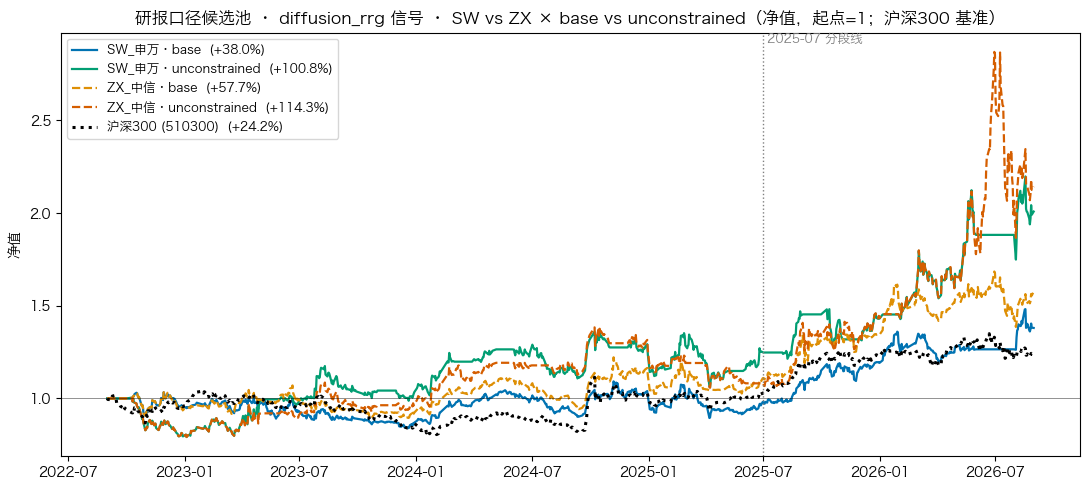

In [16]:
# 研报池四臂净值曲线（归一到起点 = 1）；_nav 供下方分段归因复用
_nav = pd.DataFrame({
    k: (pf.value().iloc[:, 0] if isinstance(pf.value(), pd.DataFrame) else pf.value())
    for k, pf in pf_report.items()
})
_nav = _nav / _nav.iloc[0]

# 沪深300 基准：用 510300.SH 的后复权收盘（adjclose）——与四臂同为后复权口径（含分红再投），
# 才是同基公平对照。⚠️ 不要用沪深300 价格指数 000300.SH：它不含分红再投，会系统性低估基准。
# 池里通常已含 510300.SH（fetch_etf_meta only_listed+drop_qdii）；缺则单独取。
if "510300.SH" in adjclose.columns:
    _hs = adjclose["510300.SH"]
else:
    _hs = fetch_etf_daily(["510300.SH"], start_date=start_date, end_date=end_date)[0]["510300.SH"]
_hs = _hs.reindex(_nav.index).ffill()
_nav["沪深300 (510300)"] = _hs / _hs.iloc[0]

# seaborn colorblind 四色：四臂各独立色（区分度远高于蓝/橙×实虚线）；实线=申万/虚线=中信保留分组
import seaborn as sns
_pal = sns.color_palette("colorblind")
_style = {"SW_申万·base": (_pal[0], "-"), "ZX_中信·base": (_pal[1], "--"),
          "SW_申万·unconstrained": (_pal[2], "-"), "ZX_中信·unconstrained": (_pal[3], "--"),
          "沪深300 (510300)": ("black", ":")}
fig, ax = plt.subplots(figsize=(11, 5))
for k in _nav.columns:
    c, ls = _style.get(k, (None, "-"))
    lw = 2.2 if k.startswith("沪深300") else 1.6
    ax.plot(_nav.index, _nav[k], color=c, ls=ls, lw=lw,
            label=f"{k}  ({_nav[k].iloc[-1] - 1:+.1%})")
ax.axvline(pd.Timestamp("2025-07-01"), color="grey", ls=":", lw=1)
ax.text(pd.Timestamp("2025-07-01"), ax.get_ylim()[1], " 2025-07 分段线", va="top", color="grey", fontsize=9)
ax.axhline(1.0, color="black", lw=0.6, alpha=0.5)
ax.set_title("研报口径候选池 · diffusion_rrg 信号 · SW vs ZX × base vs unconstrained（净值，起点=1；沪深300 基准）")
ax.set_ylabel("净值"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
ax.grid(False)
plt.tight_layout(); plt.show()


In [17]:
# 分段归因——检验优势是否仍高度集中在末段（2025-07 分段线之后，至 end_date 2026-08）
# _nav 由上一 cell 构造
_seg = {}
for _a, _b_, _lab in [(None, "2025-06-30", "2022-09~2025-06 (34个月)"),
                      ("2025-07-01", None, "2025-07~2026-08 (14个月)"),
                      (None, None, "全区间")]:
    _s = _nav.loc[_a:_b_]
    _seg[_lab] = _s.iloc[-1] / _s.iloc[0] - 1
display(pd.DataFrame(_seg).T.round(4))

,SW_申万·base,SW_申万·unconstrained,ZX_中信·base,ZX_中信·unconstrained,沪深300 (510300)
2022-09~2025-06 (34个月),-0.0187,0.2492,0.1090,0.0818,0.0287
2025-07~2026-08 (14个月),0.4093,0.6091,0.4200,0.9813,0.2053
全区间,0.3803,1.0079,0.5767,1.1427,0.2416


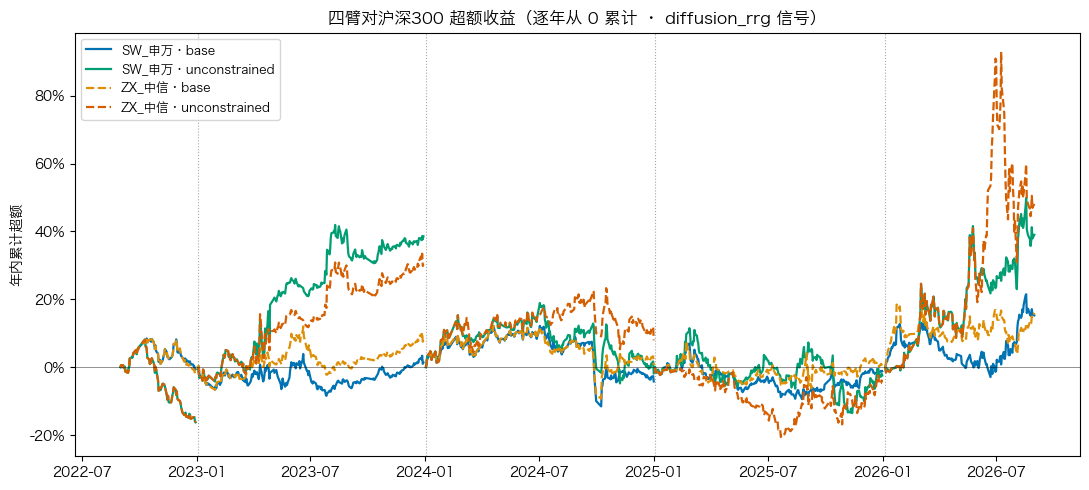

In [18]:
# 四臂对沪深300 的超额收益 —— 每个自然年从 0 重画（仿研报"逐年累计"风格）
# 超额口径：组合年内累计收益 − 沪深300 年内累计收益（两者均自年初=1 起步，差值自 0 起步）；
# 逐年重置避免复利让 2025-07 后独大掩盖前段。图上不标文字，仅 legend 区分四臂。
from matplotlib.ticker import PercentFormatter

_bench_nav = _nav["沪深300 (510300)"]
_arms = [c for c in _nav.columns if not c.startswith("沪深300")]
fig, ax = plt.subplots(figsize=(11, 5))
for arm in _arms:
    c, ls = _style.get(arm, (None, "-"))
    a, b = _nav[arm], _bench_nav
    first = True
    for _y in sorted(set(a.index.year)):
        m = a.index.year == _y
        ay, by = a[m], b[m]
        seg = (ay / ay.iloc[0]) - (by / by.iloc[0])   # 年内累计超额，起点 0
        ax.plot(seg.index, seg.values, color=c, ls=ls, lw=1.6,
                label=arm if first else None)
        first = False

# 年度分割线：每年第一个交易日画一条竖线（超额在此归零重算）；跳过首年不在数据左缘外画
for _y in sorted(set(_nav.index.year))[1:]:
    _x = _nav.index[_nav.index.year == _y][0]
    ax.axvline(_x, color="grey", ls=":", lw=0.8, alpha=0.7)

ax.axhline(0.0, color="black", lw=0.6, alpha=0.5)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_title("四臂对沪深300 超额收益（逐年从 0 累计 · diffusion_rrg 信号）")
ax.set_ylabel("年内累计超额"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
ax.grid(False)
plt.tight_layout(); plt.show()


/var/folders/jv/n9k3hyd55y5dkbzvksgw0j9c0000gn/T/ipykernel_3604/2384721532.py:16: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Hiragino Sans GB.
  plt.tight_layout(); plt.show()
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Hiragino Sans GB.
  fig.canvas.print_figure(bytes_io, **kw)


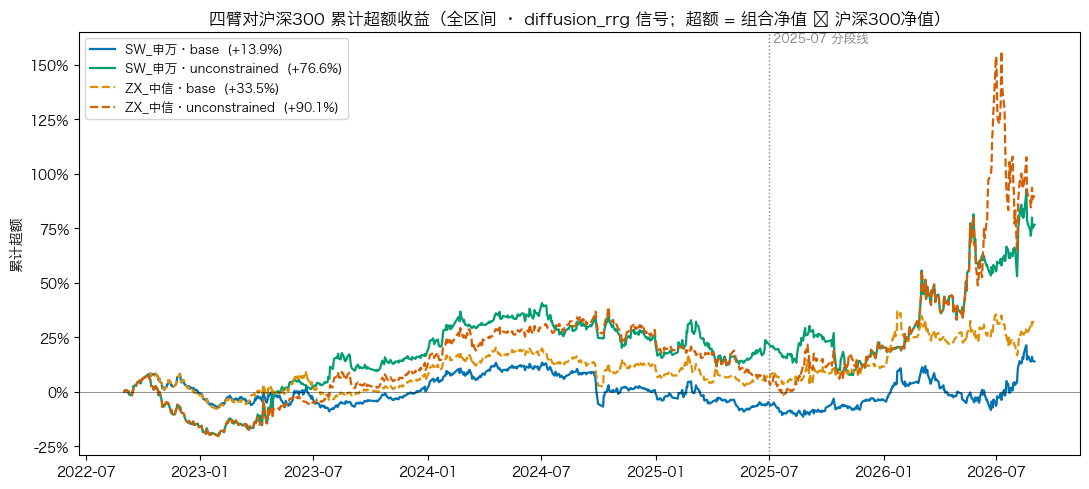

In [19]:
# 四臂对沪深300 累计超额收益（全区间不重置，对应上面的净值图）
# 超额 = 组合净值 − 沪深300净值（两者均起点=1 → 累计超额起点 0）；_arms / _bench_nav / PercentFormatter 复用上一 cell
fig, ax = plt.subplots(figsize=(11, 5))
for arm in _arms:
    c, ls = _style.get(arm, (None, "-"))
    exc = _nav[arm] - _bench_nav
    ax.plot(exc.index, exc.values, color=c, ls=ls, lw=1.6,
            label=f"{arm}  ({exc.iloc[-1]:+.1%})")
ax.axhline(0.0, color="black", lw=0.6, alpha=0.5)
ax.axvline(pd.Timestamp("2025-07-01"), color="grey", ls=":", lw=1)
ax.text(pd.Timestamp("2025-07-01"), ax.get_ylim()[1], " 2025-07 分段线", va="top", color="grey", fontsize=9)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_title("四臂对沪深300 累计超额收益（全区间 · diffusion_rrg 信号；超额 = 组合净值 − 沪深300净值）")
ax.set_ylabel("累计超额"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
ax.grid(False)
plt.tight_layout(); plt.show()


# 汇总对照表（行业指数层全部信号）

每格 = 一个绩效指标；列两级 = （体系 × 日频/月末）。ETF 段因月末采样内建于链条、无日频版本，单独在上节展示。

In [20]:
pd.concat(
    {name: pd.concat({
        arm: pd.concat({"日频": portfolio_stats(pf_d), "月末": portfolio_stats(pf_m)}, axis=1)
        for arm, (pf_d, pf_m) in arms.items()}, axis=1)
     for name, arms in results.items()},
    axis=1,
)

象限1                                              象限2  \
                SW_申万                   ZX_中信                    SW_申万   
                   日频          月末          日频          月末           日频   
累计收益率        0.078452    0.229626    0.264908    0.333725     0.152739   
年化收益率        0.020676    0.057610    0.063155    0.077934     0.039267   
最大回撤        -0.314194   -0.262077   -0.280089   -0.241892    -0.318836   
年化波动率        0.220860    0.211281    0.215586    0.211860     0.201454   
夏普比率         0.203987    0.371848    0.392209    0.460402     0.291486   
Calmar 比率    0.065807    0.219821    0.225481    0.322186     0.123157   
总成交笔数      835.000000  293.000000  904.000000  306.000000  1327.000000   

                                                       象限3              ...  \
                             ZX_中信                   SW_申万              ...   
                   月末           日频          月末          日频          月末  ...   
累计收益率        0.168955     0.244817    0.309975   -0.075224   -0.095584  ...   
年化收益率        0.043208     0.058728    0.072899   -0.020968   -0.026856  ...   
最大回撤        -0.270845    -0.366314   -0.319586   -0.373104   -0.345329  ...   
年化波动率        0.197128     0.201534    0.198684    0.192811    0.177788  ...   
夏普比率         0.312567     0.383125    0.452800   -0.013693   -0.063967  ...   
Calmar 比率    0.159531     0.160322    0.228104   -0.056198   -0.077769  ...   
总成交笔数      321.000000  1103.000000  312.000000  895.000000  315.000000  ...   

                象限2+3                      扩散                          \
                ZX_中信                   SW_申万                   ZX_中信   
                   日频          月末          日频          月末          日频   
累计收益率        0.105676    0.048428    0.206062    0.359552    0.314763   
年化收益率        0.026525    0.012400    0.052080    0.086791    0.073919   
最大回撤        -0.324099   -0.361767   -0.217721   -0.197149   -0.196832   
年化波动率        0.197987    0.183958    0.189607    0.182713    0.190817   
夏普比率         0.230823    0.158777    0.363617    0.547870    0.469686   
Calmar 比率    0.081842    0.034278    0.239203    0.440230    0.375545   
总成交笔数      851.000000  315.000000  569.000000  228.000000  594.000000   

                           扩散+RRG                                      
                            SW_申万                   ZX_中信              
                   月末          日频          月末          日频          月末  
累计收益率        0.351341    0.040773    0.096319    0.242967    0.341407  
年化收益率        0.081627    0.010888    0.025231    0.058318    0.079549  
最大回撤        -0.194341   -0.345624   -0.299722   -0.288531   -0.225025  
年化波动率        0.184970    0.212249    0.203589    0.223406    0.205912  
夏普比率         0.516994    0.158213    0.225430    0.366231    0.475332  
Calmar 比率    0.420017    0.031502    0.084181    0.202120    0.353511  
总成交笔数      264.000000  572.000000  217.000000  558.000000  216.000000  

[7 rows x 40 columns]

> **归因边界**：申万一级 31 个行业、中信一级 30 个，且两者**行业定义切法不同**（例如中信「电力设备及新能源」与申万「电力设备」/「公用事业」的拆分口径不一致）。因此上表若显示中信更优，差异**同时来自「分类质量」与「行业颗粒度」两个来源**，不能干净归因为「中信分类更好」。
>
> 另一处有意的不对称：`exclude` 两侧不同——申万一级没有「综合金融」，只能剔「综合」；中信两者都有，故中信版严格对齐研报「剔除综合、综合金融」原文，申万版做不到。这是研报口径对齐上的**真实优势**，但也意味着两臂的基准篮子成分不完全可比。